# 소셜미디어 분석

인플루언서 영향력 측정

In [15]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [26]:
df = pd.read_csv('top_insta_influencers_data.csv')
df

,rank,channel_info,influence_score,posts,followers,avg_likes,60_day_eng_rate,new_post_avg_like,total_likes,country
0,1,cristiano,92,3.3k,475.8m,8.7m,1.39%,6.5m,29.0b,Spain
1,2,kyliejenner,91,6.9k,366.2m,8.3m,1.62%,5.9m,57.4b,United States
2,3,leomessi,90,0.89k,357.3m,6.8m,1.24%,4.4m,6.0b,NaN
3,4,selenagomez,93,1.8k,342.7m,6.2m,0.97%,3.3m,11.5b,United States
4,5,therock,91,6.8k,334.1m,1.9m,0.20%,665.3k,12.5b,United States
...,...,...,...,...,...,...,...,...,...,...
195,196,iambeckyg,71,2.3k,33.2m,623.8k,1.40%,464.7k,1.4b,United States
196,197,nancyajram,81,3.8k,33.2m,390.4k,0.64%,208.0k,1.5b,France
197,198,luansantana,79,0.77k,33.2m,193.3k,0.26%,82.6k,149.2m,Brazil
198,199,nickjonas,78,2.3k,33.0m,719.6k,1.42%,467.7k,1.7b,United States


## Data preprocessing

In [7]:
# 1. 데이터 프레임 구조
print(f'데이터 Shap: {df.shape}')

# 2. 칼럼별 데이터 타입 확인
print(f'\n 데이터 타입: \n {df.dtypes}')

# 3. 결측치 확인
print(f'\n 결측치 개수: \n {df.isnull().sum()}')

데이터 Shap: (200, 10)

 데이터 타입: 
 rank                  int64
channel_info         object
influence_score       int64
posts                object
followers            object
avg_likes            object
60_day_eng_rate      object
new_post_avg_like    object
total_likes          object
country              object
dtype: object

 결측치 개수: 
 rank                  0
channel_info          0
influence_score       0
posts                 0
followers             0
avg_likes             0
60_day_eng_rate       0
new_post_avg_like     0
total_likes           0
country              62
dtype: int64


In [27]:
# country null to none
df['country'] = df['country'].fillna('None')
print(f'확인: {df['country'].isnull().sum()}')

확인: 0


In [28]:
# 수치형(k, m 등) 숫자 변환
def convert_to_num(x):
    if isinstance(x, str):
        x = x.lower().replace(',', '').strip()
        if 'k' in x:
            return float(x.replace('k', '')) * 1000
        elif 'm' in x:
            return float(x.replace('m', '')) * 1000000
        elif 'b' in x:
            return float(x.replace('b', '')) * 1000000000
        else:
            try:
                return float(x)
            except:
                return None
    return x

# 퍼센트 문자열 to 소수
def convert_per(x):
    if isinstance(x, str) and '%' in x:
        return float(x.replace('%', '').strip()) / 100
    return x

# 변환 칼럼 리스트
col_to_convert = ['posts', 'followers', 'avg_likes', 'new_post_avg_like', 'total_likes']
for col in col_to_convert:
    df[col] = df[col].apply(convert_to_num)

df['60_day_eng_rate'] = df['60_day_eng_rate'].apply(convert_per)

df

,rank,channel_info,influence_score,posts,followers,avg_likes,60_day_eng_rate,new_post_avg_like,total_likes,country
0,1,cristiano,92,3300.0,475800000.0,8700000.0,0.0139,6500000.0,2.900000e+10,Spain
1,2,kyliejenner,91,6900.0,366200000.0,8300000.0,0.0162,5900000.0,5.740000e+10,United States
2,3,leomessi,90,890.0,357300000.0,6800000.0,0.0124,4400000.0,6.000000e+09,None
3,4,selenagomez,93,1800.0,342700000.0,6200000.0,0.0097,3300000.0,1.150000e+10,United States
4,5,therock,91,6800.0,334100000.0,1900000.0,0.0020,665300.0,1.250000e+10,United States
...,...,...,...,...,...,...,...,...,...,...
195,196,iambeckyg,71,2300.0,33200000.0,623800.0,0.0140,464700.0,1.400000e+09,United States
196,197,nancyajram,81,3800.0,33200000.0,390400.0,0.0064,208000.0,1.500000e+09,France
197,198,luansantana,79,770.0,33200000.0,193300.0,0.0026,82600.0,1.492000e+08,Brazil
198,199,nickjonas,78,2300.0,33000000.0,719600.0,0.0142,467700.0,1.700000e+09,United States


## EDA

팔로워 수에 비해 평균 좋아요 수가 적은 계정 확인

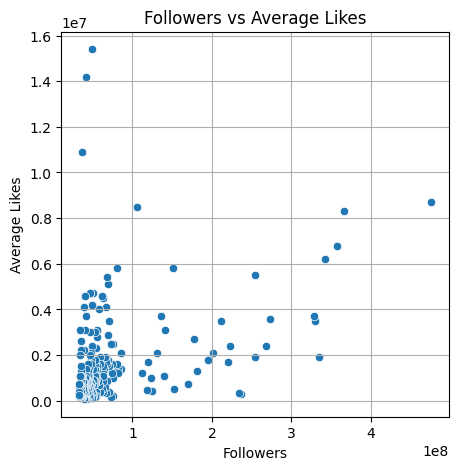

In [29]:
plt.figure(figsize=(5,5))
sns.scatterplot(data= df, x='followers', y='avg_likes')

plt.title('Followers vs Average Likes')
plt.xlabel('Followers')
plt.ylabel('Average Likes')
plt.grid(True)
plt.show()

In [34]:
# 상위 25% follwers & 하위 25% avg_likes 필터링 확인해보기
f10 = df['followers'].quantile(.75)
l10 = df['avg_likes'].quantile(.25)

# 필터링
low_eng_acc = df[(df['followers'] >=  f10) & (df['avg_likes'] <= l10)]

# 확인
low_eng_acc

,rank,channel_info,influence_score,posts,followers,avg_likes,60_day_eng_rate,new_post_avg_like,total_likes,country
11,12,natgeo,91,10000.0,237000000.0,302200.0,0.0007,159300.0,3.000000e+09,United States
12,13,nike,90,950.0,234100000.0,329000.0,0.0008,181800.0,3.136000e+08,United States
27,28,theellenshow,87,10000.0,125100000.0,420500.0,0.0007,81700.0,4.200000e+09,United States
30,31,chrisbrownofficial,86,7300.0,118500000.0,463200.0,0.0022,255900.0,3.400000e+09,United States
40,41,snoopdogg,86,10000.0,75300000.0,203700.0,0.0017,125800.0,2.000000e+09,None
44,45,victoriassecret,88,2900.0,73200000.0,147000.0,0.0004,29800.0,4.235000e+08,United States
47,48,nba,87,12900.0,70100000.0,370800.0,0.0028,196900.0,4.800000e+09,United States


팔로워 수에 비해 반응이 적은 계정들

이때 드는 생각은 influence_score. 

값들 자체가 높다. 그럼 해당 지표가 잘못된건가? 

팔로워 수가 많은 계정이 항상 높은 influence score가지는지 확인

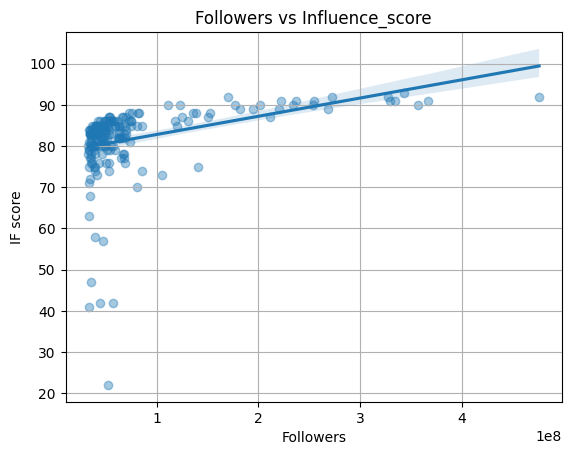

In [36]:
sns.regplot(df, x='followers', y='influence_score', scatter_kws = {'alpha': 0.4})

plt.title('Followers vs Influence_score')
plt.xlabel('Followers')
plt.ylabel('IF score')
plt.grid(True)
plt.show()

In [39]:
corr = df[['followers', 'influence_score']].corr().iloc[0,1]
print(f'상관 : {corr:.3f}')

상관 : 0.368


상관 있긴한데.. 그래프 자체를 보면 좀 다른 생각. 

팔로워 적어도 높은 스코어 가진 경우가 대부분임

그럼 팔로워 대비 실제로 반응이 높은 인플루언서는??


- Engagement Rate = avg_likes/followers 지표로 확인해보자

In [41]:
# eng_rate 
df['eng_rate'] = df['avg_likes']/df['followers']

In [44]:
# 참여율 기준 상위 10명
top_engaged = df.sort_values(by='eng_rate', ascending=False).head(10)
print("참여율이 높은 인플루언서")
print(top_engaged[['channel_info', 'followers', 'avg_likes', 'eng_rate']])

# 참여율 기준 하위 10명
low_engaged = df.sort_values(by='eng_rate', ascending=True).head(10)
print("\n 참여율이 낮은 인플루언서")
print(low_engaged[['channel_info', 'followers', 'avg_likes', 'eng_rate']])


참여율이 높은 인플루언서
        channel_info   followers   avg_likes  eng_rate
140              j.m  41900000.0  14200000.0  0.338902
102              thv  49300000.0  15400000.0  0.312373
167            rkive  37000000.0  10900000.0  0.294595
147  jenniferaniston  40700000.0   4600000.0  0.113022
155         mahi7781  39100000.0   4100000.0  0.104859
118             zayn  46500000.0   4700000.0  0.101075
114      harrystyles  46900000.0   4700000.0  0.100213
97             adele  50700000.0   4700000.0  0.092702
186      blakelively  34600000.0   3100000.0  0.089595
138       badbunnypr  42100000.0   3700000.0  0.087886

 참여율이 낮은 인플루언서
        channel_info    followers  avg_likes  eng_rate
11            natgeo  237000000.0   302200.0  0.001275
12              nike  234100000.0   329000.0  0.001405
134    buzzfeedtasty   43200000.0    65100.0  0.001507
44   victoriassecret   73200000.0   147000.0  0.002008
144             dior   41500000.0    88800.0  0.002140
161               hm   38500000.0  

## 영향 요인 분석

그럼.. 최강 인플루언서가 되기 위한 조건은?

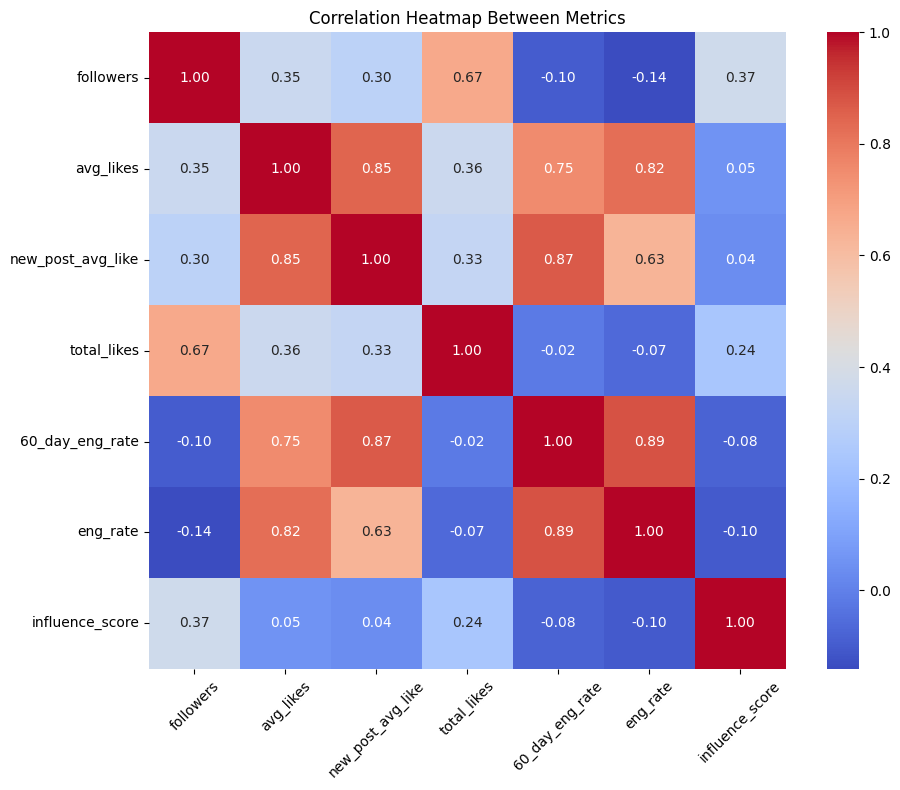

In [46]:
## heatmap 상관 확인

numeric_cols = ['followers', 'avg_likes', 'new_post_avg_like', 'total_likes',
                '60_day_eng_rate', 'eng_rate', 'influence_score']

# 상관계수 계산
corr_matrix = df[numeric_cols].corr()

# 히트맵 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)

plt.title("Correlation Heatmap Between Metrics")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

파생 변수인 eng_rate 제외하고 팔로워랑 전체 좋아요 수는 상관.. 왜 influence score는 높은 상관 있는게 없는가?.. RF로 한번 확인해보자

In [51]:
# X, y
feature_cols = ['followers', 'avg_likes', 'new_post_avg_like', 'total_likes', '60_day_eng_rate', 'eng_rate']
X = df[feature_cols]
y = df['influence_score']

# train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=42)

# model train(no tunning)
model = RandomForestRegressor(n_estimators = 200, max_depth=2, random_state=42)
model.fit(X_train, y_train)

# prediction
y_pred = model.predict(X_test)

# 성능 평가
print(f'R: {r2_score(y_test, y_pred)}')
print(f'\n MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'\n RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}')

R: 0.01438574976580631

 MAE: 5.441713573930055

 RMSE: 11.428918199143066


우선 R값 자체가 높지 않다. 어쩔 수 없는 부분이고 RMSE의 경우도 그렇게 좋은 것 같지는 않다.

그래도 영향 요인을 확인해보자

Not SHAP just importance

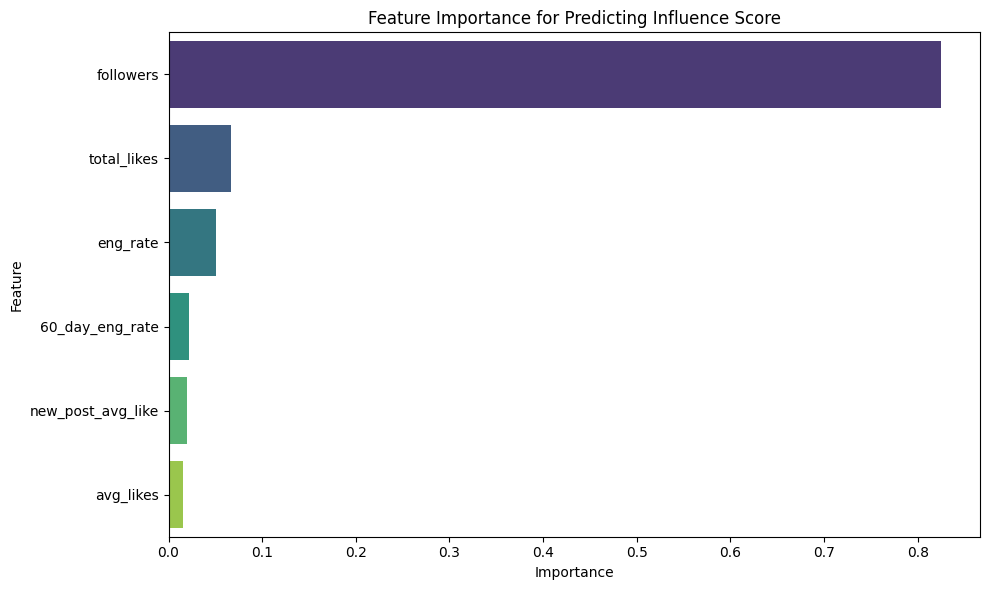

In [52]:
# Feature Importance 추출
importances = model.feature_importances_
feat_importance_df = pd.DataFrame({'feature': feature_cols, 'importance': importances}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_importance_df, x='importance', y='feature', palette='viridis')
plt.title("Feature Importance for Predicting Influence Score")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

팔로워 수 자체가 압도적 영향력..

앞선 산점도에서 봤듯이 애초에 influence score가 대부분 80이상이고 그 값들의 계정 팔로워 수가 다 적음. 어찌보면 당연한 결과

그럼 예외는??

In [54]:
# 기준값 계산
followers_25 = df['followers'].quantile(0.25)
score_75 = df['influence_score'].quantile(0.65)

# 예외 케이스 필터링
low_follower_high_score = df[(df['followers'] <= followers_25) & (df['influence_score'] >= score_75)]

# 주요 정보 정리
low_follower_high_score = low_follower_high_score[['channel_info', 'followers', 'influence_score',
                                                    'avg_likes', 'eng_rate', '60_day_eng_rate']]

print("예외 케이스: 팔로워 수는 낮지만 influence_score가 높은 계정")
display(low_follower_high_score)


예외 케이스: 팔로워 수는 낮지만 influence_score가 높은 계정


,channel_info,followers,influence_score,avg_likes,eng_rate,60_day_eng_rate
149,andresiniesta8,40000000.0,85,250800.0,0.006270,0.0041
162,anushkasen0408,38300000.0,85,695400.0,0.018157,0.0175
170,gisel_la,36500000.0,85,150500.0,0.004123,0.0010
